## 章末問題 2.3

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.stats import norm

data = pd.read_csv("sensor_data_200.txt",delimiter=' ',
                  header=None,names=("deta","time","ir","lidar"))

mean = data["lidar"].mean()
var = data["lidar"].var(ddof=0)

p = 1-var/mean
n = round(mean**2/(mean-var))    #試行数は整数とする

print(f"""
センサ値の平均値:{mean}
センサ値の標本分散:{var}
成功率p:{p}
試行数n:{n}
""")


センサ値の平均値:209.73713297619855
センサ値の標本分散:23.407709770274106
成功率p:0.8883950140916131
試行数n:236



In [5]:
def combination(x):           #Combination nCxの計算を行う関数
    return math.comb(n,x)     #math.com(n,x)はnCxの計算を行うモジュール

## 二項分布の式  

${P}_{(x)} = _nC_x  p^x(1-p)^{(n-x)}$　　　$x=(1,2,.....,n)$

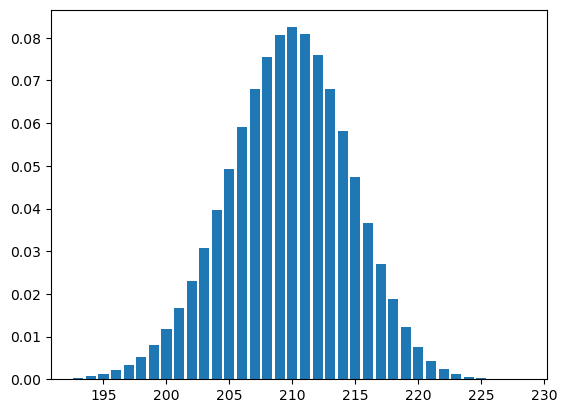

In [23]:
P = [combination(x)*(p**x)*((1-p)**(n-x)) for x in range(min(data["lidar"]),max(data["lidar"]))]
plt.bar(range(min(data["lidar"]),max(data["lidar"])),P)
plt.show()

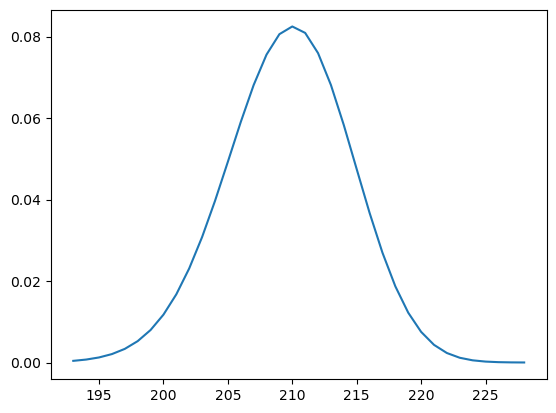

In [12]:
from scipy.stats import binom  #二項分布を求めるモジュール
xl = range(min(data["lidar"]),max(data["lidar"]))
yl = binom.pmf(xl,n,p)         #binom.pmf(成功回数,試行回数,成功確率)
plt.plot(xl,yl)
plt.show()